# Математическая статистика для анализа больших данных.
## Задание 12
### Байесовский подход к статистике

Выполненную работу нужно отправить телеграм-боту  `@stats_bd_bot`
* Дедлайн см. в телеграм-боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* По практическим задачам прислать нужно ноутбук в формате `ipynb`.
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Не забывайте делать пояснения и выводы.
* Решение теоретических задач можете записывать в markdown с помощью TeX, присылать в виде фотографий или вшивать в ноутбук через Insert Image (убеждайтесь, что картинка сохраняется при перемещении ноутбука в другое место)

In [ ]:
# Bot check

# HW_ID: sbd_hw12
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as sps

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import warnings

sns.set(palette='Set2')
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Задача 1 (5 баллов)

**1)** В схеме испытаний Бернулли из задачи 1 рассмотрим онлайн-подход: наблюдения поступают батчами, в качестве априорного используется предыдущее апостериорное. Сначала реализуйте функцию генерации батчей:

In [1]:
def get_sample_bern(theta=0.5, batch_size=5):
    '''
    :returns: батч размера <batch_size> из распределения Bern(<theta>)
    '''
    # Генерируем batch_size наблюдений из Bernoulli(theta)
    return sps.bernoulli(theta).rvs(size=batch_size)


Допишите функцию, имитирующую онлайн подход:

In [3]:
def bern_posterior_params(batch_count, a_prior, b_prior, theta=0.5, batch_size=5):
    '''
    :param batch_count: количество батчей в выборке
    :param a_prior, b_prior: параметры априорного распределения (до получения выборки)
    :param theta: истинный параметр распределения бернулли
    :param batch_size: размер батча. Размер выборки в таком случае <batch_size> * <batch_count>

    :returns: набор апостериорных параметров, полученных после каждого нового батча
    '''
    a_post = a_prior
    b_post = b_prior
    post_params = [(a_post, b_post)]
    for _ in range(batch_count):
        batch = get_sample_bern(theta=theta, batch_size=batch_size)
        a_post = a_post + np.sum(batch)
        b_post = b_post + batch_size - np.sum(batch)
        post_params.append((a_post, b_post))
    return np.array(post_params)


Ниже приведена реализация вспомогательной функции

In [4]:
def draw_posteriori(grid, distr_class, post_params, xlim=None):
    '''Рисует серию графиков апостериорных плотностей.

    :param grid: сетка для построения графика
    :param distr_class: класс распределений из scipy.stats
    :param post_params: параметры апостериорных распределений
        shape=(размер выборки, кол-во параметров)
    '''

    size = post_params.shape[0] - 1

    plt.figure(figsize=(12, 7))
    for n in range(size+1):
        plt.plot(grid,
                 distr_class(post_params[n]).pdf(grid) \
                     if np.isscalar(post_params[n]) \
                     else distr_class(*post_params[n]).pdf(grid),
                 label='n={}: {}'.format(n, np.round(post_params[n], 3)),
                 lw=2.5,
                 color=(1-n/size, n/size, 0))
    plt.title('Апостериорное распределение в зависимости от номера батча')
    plt.legend(fontsize=12)
    plt.xlim(xlim)
    plt.show()

Рассмотрите произвольную монету. Подберите два априорных распределения так, что в одном случае априорные знания должны совпадать с реальностью, а во втором нет. Рассмотрите как изменяется апостериорное распределение в зависимости от получения нового батча.

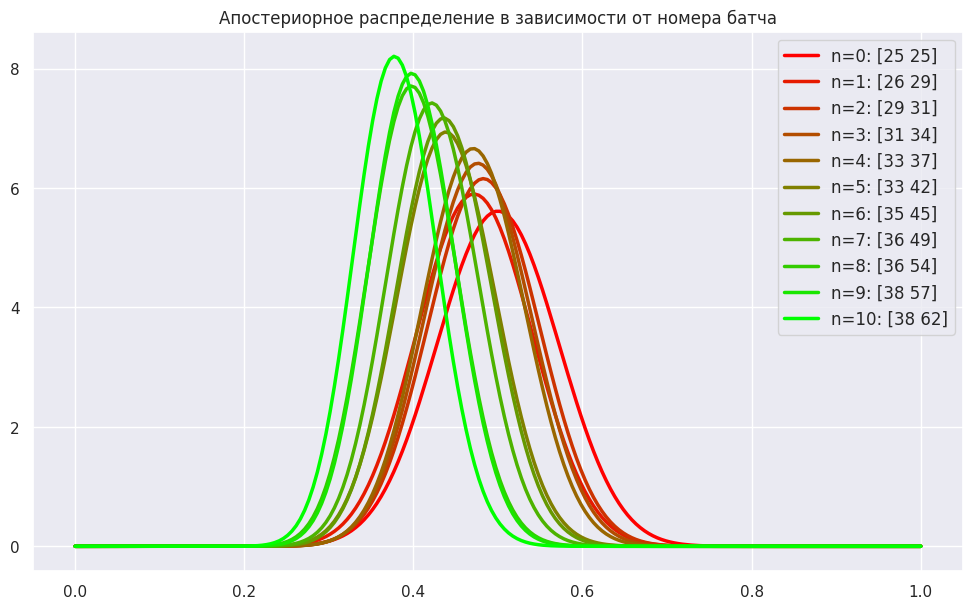

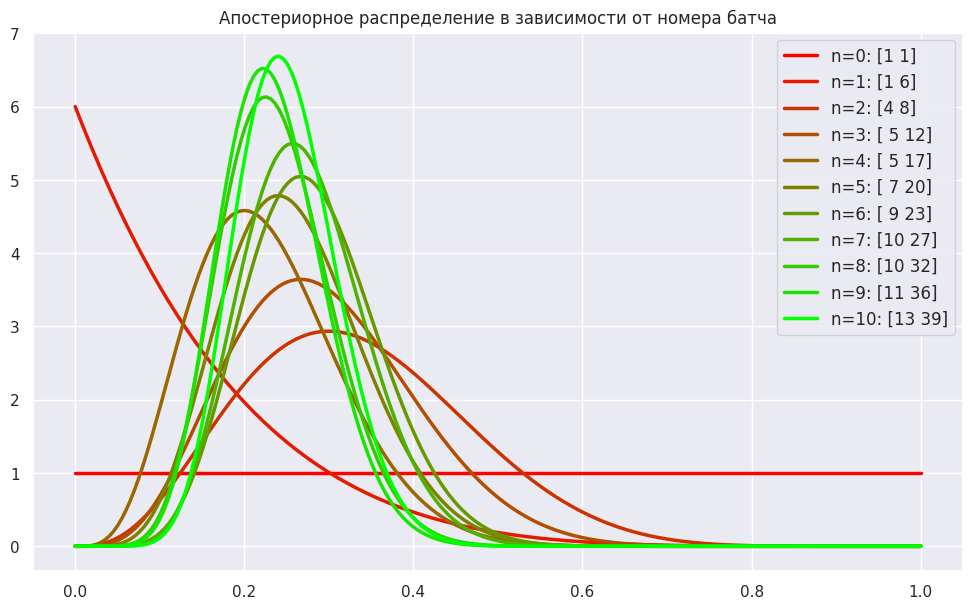

In [5]:
theta_true = 0.3
batch_count = 10
batch_size = 5
grid = np.linspace(0, 1, 200)

# Априор 1: Сильная уверенность в честности (несоответствие реальности)
a_prior1, b_prior1 = 25, 25
params1 = bern_posterior_params(batch_count, a_prior1, b_prior1, theta=theta_true, batch_size=batch_size)
draw_posteriori(grid, sps.beta, params1)

# Априор 2: Равномерный (неинформативный), ближе к реальности
a_prior2, b_prior2 = 1, 1
params2 = bern_posterior_params(batch_count, a_prior2, b_prior2, theta=theta_true, batch_size=batch_size)
draw_posteriori(grid, sps.beta, params2)


*На графиках видно, как по мере поступления новых батчей данных апостериорная плотность постепенно сдвигается к истинному параметру θ. Если априор сильно смещён от реальности, изначально апостериор плотен вокруг неверной моды, но с ростом объёма данных становится более узким и концентрируется возле истинного θ. Если априор нейтрален или близок к реальности, апостериорная оценка быстрее достигает корректных значений. Теоретически для бернуллиевских испытаний с Beta-априором апостериор тоже остаётся Beta, сужается и тяготеет к истинному параметру по мере увеличения выборки, что и наблюдается на графиках.*

---
## Задача 2 (5 баллов)

**1)** Пусть дана выборка $X_1, \dots, X_n$ из распределения $Exp(\theta)$, а в качестве априорного распределения для $\theta$ выбрано $\Gamma(\alpha, \beta)$. Апостериорное распределение вычисляется по формуле:
$$q\left.(t\,\right|\,x) = \frac {q(t) p_t(x_1) ... p_t(x_n)} {\int\limits_\Theta q(t) p_t(x_1) ... p_t(x_n) dt} \propto q(t) p_t(x_1) ... p_t(x_n),$$
где $p_t(x)$ — плотность распределения $Exp(\theta)$, а $q(t)$ — плотность распределения $\Gamma(\alpha, \beta)$.
В таком случае,
$$q(t\,|\,X) \propto t^n \exp(-t \sum\limits_{i=1}^n{X_i}) \cdot t^{\beta - 1} \exp(-\alpha t) = t^{\beta + n -1} \exp{\left(-t (\alpha + \sum\limits_{i=1}^n{X_i})\right)}$$
Значит, апостериорным распределением является $\Gamma(\alpha + \sum X_i, \beta + n)$.

Сгенерируйте выборку из экспоненциального распределения:

In [6]:
true_theta = 2.0
n = 50
sample_exp = sps.expon(scale=1/true_theta).rvs(size=n)  # scale=1/θ


Выберите параметры $\alpha$ и $\beta$ априорного распределения:

In [7]:
alpha_prior = 2.0
beta_prior = 2.0


Рассчитайте параметры апостериорного распределения:

In [8]:
alpha_post = alpha_prior + np.sum(sample_exp)
beta_post = beta_prior + n

posterior_exp = sps.gamma(a=beta_post, scale=1/alpha_post)  # gamma(a=k, scale=1/λ), но тут a=β', λ=1/(α'),
# Будьте внимательны: Формулы апостериора обычно в параметризации Gamma(α,β): α - rate, β - shape или наоборот.
# Проверим параметризацию:
# Если q(t|X) = Gamma(α_post, β_post) в форме q(t) ∝ t^{β_post-1} e^{-α_post t},
# то scipy.stats.gamma(a=shape, scale=1/rate).
# Здесь rate = α_post, shape = β_post => a=β_post, scale=1/α_post корректно.

Нарисуйте на одном графике априорную и полученную апостериорную плотности. Отметьте истинное значение $\theta$, а также математическое ожидание и моду апостериорного распределения:

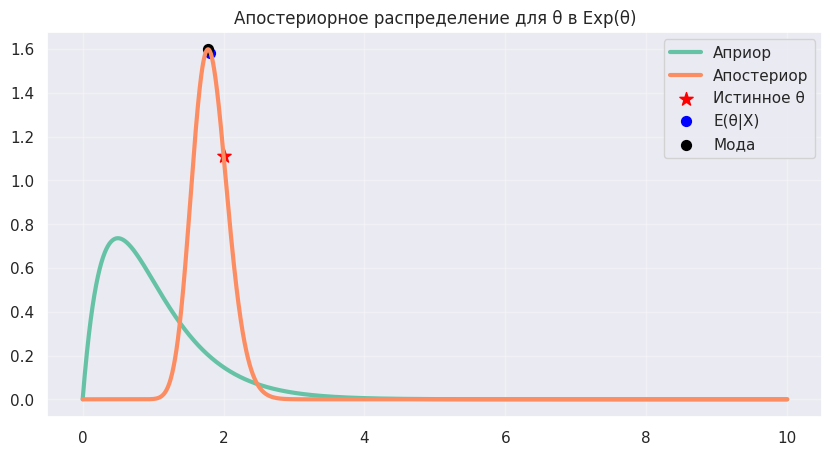

In [9]:
grid_exp = np.linspace(0, 10, 2000)

# Априорное распределение:
prior_exp = sps.gamma(a=beta_prior, scale=1/alpha_prior)

plt.figure(figsize=(10,5))
plt.plot(grid_exp, prior_exp.pdf(grid_exp), label='Априор', lw=3)
plt.plot(grid_exp, posterior_exp.pdf(grid_exp), label='Апостериор', lw=3)

mean_post = beta_post / alpha_post
mode_post = (beta_post - 1) / alpha_post if beta_post > 1 else 0

plt.scatter(true_theta, posterior_exp.pdf(true_theta), s=100, c='r', marker='*', label='Истинное θ')
plt.scatter(mean_post, posterior_exp.pdf(mean_post), s=50, c='blue', label='E(θ|X)')
plt.scatter(mode_post, posterior_exp.pdf(mode_post), s=50, c='black', label='Мода')

plt.title('Апостериорное распределение для θ в Exp(θ)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Для апостериорного распределения рассчитайте какой-нибудь доверительный интервал уровня доверия 0.95. Например, в качестве границ интервала можно рассмотреть квантили распределения. Попало ли истинное значение параметра в интервал?

In [10]:
ci_low = posterior_exp.ppf(0.025)
ci_high = posterior_exp.ppf(0.975)
print("95% доверительный интервал:", (ci_low, ci_high))
print("Попало ли истинное значение в интервал?", ci_low <= true_theta <= ci_high)

95% доверительный интервал: (1.3550307125492156, 2.3396376608213565)
Попало ли истинное значение в интервал? True


Найдите апостериорные вероятности $P(\theta > 3\,|\,X)$ и $P(\theta \leq 2\,|\,X)$:

In [11]:
p_theta_greater_3 = 1 - posterior_exp.cdf(3)
p_theta_le_2 = posterior_exp.cdf(2)
p_theta_greater_3, p_theta_le_2

(3.143352595702531e-05, 0.7763826392029622)

**2)** Пусть теперь $X_1, \dots, X_n \sim \mathcal{N}(\theta, 1)$. Рассмотрите сопряженное распределение в качестве априорного для $\theta$ и посчитайте соответствующее апостериорное:

Теперь пусть $X_i \sim \mathcal{N}(\theta, 1)$, априор: $\mathcal{N}(\mu_0, \sigma_0^2)$.Априорное распределение для $\theta$:
$$
\theta \sim \mathcal{N}(\mu_0, \sigma_0^2),
$$
что означает:
$$
\pi(\theta) = \frac{1}{\sqrt{2\pi}\sigma_0} \exp\left(-\frac{(\theta - \mu_0)^2}{2\sigma_0^2}\right).
$$

#### Правдоподобие для выборки $X_1, \dots, X_n$:
При известной дисперсии $\sigma^2 = 1$ (вариация = 1) и среднем $\theta$:
$$
L(\theta \mid X_1, \dots, X_n) = \prod_{i=1}^n f_{X \mid \theta}(x_i) = \left(\frac{1}{\sqrt{2\pi}}\right)^n \exp\left(-\frac{1}{2} \sum_{i=1}^n (x_i - \theta)^2\right).
$$


По теореме Байеса апостериорное распределение $\theta \mid X$ пропорционально произведению априорного распределения на правдоподобие:
$$
p(\theta \mid X) \propto \pi(\theta) L(\theta \mid X).
$$

Подставляя выражения:
$$
p(\theta \mid X) \propto \frac{1}{\sigma_0 \sqrt{2\pi}} \exp\left(-\frac{(\theta - \mu_0)^2}{2\sigma_0^2}\right) \cdot \left(\frac{1}{\sqrt{2\pi}}\right)^n \exp\left(-\frac{1}{2} \sum_{i=1}^n (x_i - \theta)^2\right).
$$

Соберём экспоненты:
$$
p(\theta \mid X) \propto \exp\left(-\frac{(\theta - \mu_0)^2}{2\sigma_0^2} - \frac{1}{2} \sum_{i=1}^n (x_i - \theta)^2\right).
$$

Распишем сумму квадратов:
$$
\sum_{i=1}^n (x_i - \theta)^2 = \sum_{i=1}^n \left(x_i^2 - 2x_i\theta + \theta^2\right) = \sum_{i=1}^n x_i^2 - 2\theta \sum_{i=1}^n x_i + n\theta^2.
$$

Также расписываем:
$$
(\theta - \mu_0)^2 = \theta^2 - 2\theta\mu_0 + \mu_0^2.
$$

Подставляя, показатель экспоненты становится:
$$
-\frac{(\theta - \mu_0)^2}{2\sigma_0^2} - \frac{1}{2} \sum_{i=1}^n (x_i - \theta)^2 =
-\frac{1}{2} \left(\frac{\theta^2 - 2\theta\mu_0 + \mu_0^2}{\sigma_0^2}\right) - \frac{1}{2} \left(\sum_{i=1}^n x_i^2 - 2\theta \sum_{i=1}^n x_i + n\theta^2\right).
$$

Сгруппируем члены по $\theta$:
$$
-\frac{1}{2} \left(\frac{1}{\sigma_0^2} + n\right) \theta^2 + \left(\frac{\mu_0}{\sigma_0^2} + \sum_{i=1}^n x_i\right) \theta + \text{константы}.
$$


Для нормального распределения $\mathcal{N}(\mu, \tau^2)$ плотность имеет вид:
$$
\propto \exp\left(-\frac{(\theta - \mu)^2}{2\tau^2}\right).
$$

Сравнивая с полученным выражением, находим:

1. **Обратная дисперсия апостериорного распределения**:
$$
\frac{1}{\tau^2} = \frac{1}{\sigma_0^2} + n \quad \Rightarrow \quad \tau^2 = \frac{1}{\frac{1}{\sigma_0^2} + n}.
$$

2. **Среднее апостериорного распределения**:
$$
\mu = \frac{\frac{\mu_0}{\sigma_0^2} + \sum_{i=1}^n x_i}{\frac{1}{\sigma_0^2} + n}.
$$

---

Апостериорное распределение $\theta \mid X$:
$$
\theta \mid X \sim \mathcal{N}\left(
\frac{\mu_0 \sigma_0^2 + \sum x_i}{\sigma_0^2 + n},
\frac{1}{\frac{1}{\sigma_0^2} + n}
\right).
$$



Тогда апостериор для $\theta$ будет тоже нормальный:

$$
\theta \mid X \sim \mathcal{N}\left(
\frac{\mu_0 \sigma_0^2 + \sum x_i}{\sigma_0^2 + n},
\frac{1}{\frac{1}{\sigma_0^2} + n}
\right).
$$


Для данных распределений проведите исследования, аналогичные пункту 1):

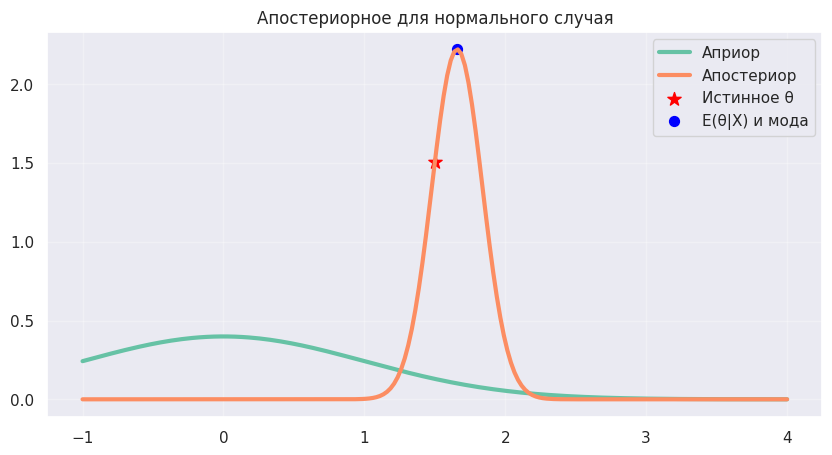

95% доверительный интервал (норм): (1.3066199198966544, 2.01065976670649)
Попало ли истинное значение в интервал? True


(0.028676366286087385, 0.00012263377078481502)

In [12]:
# Параметры
true_theta_norm = 1.5
n_norm = 30
sample_norm = sps.norm(loc=true_theta_norm, scale=1).rvs(size=n_norm)

# Априорные параметры для нормального априора:
mu_0 = 0.0
sigma_0 = 1.0

sum_x = np.sum(sample_norm)
post_mean = ( (mu_0/(sigma_0**2)) + sum_x ) / ( (1/(sigma_0**2)) + n_norm )
post_var = 1 / ((1/(sigma_0**2)) + n_norm)

posterior_norm = sps.norm(loc=post_mean, scale=np.sqrt(post_var))

grid_norm = np.linspace(-1, 4, 200)
prior_norm = sps.norm(loc=mu_0, scale=sigma_0)

plt.figure(figsize=(10,5))
plt.plot(grid_norm, prior_norm.pdf(grid_norm), label='Априор', lw=3)
plt.plot(grid_norm, posterior_norm.pdf(grid_norm), label='Апостериор', lw=3)

mean_post_norm = post_mean
mode_post_norm = post_mean  # Для нормального распределения мода=среднее
plt.scatter(true_theta_norm, posterior_norm.pdf(true_theta_norm), s=100, c='r', marker='*', label='Истинное θ')
plt.scatter(mean_post_norm, posterior_norm.pdf(mean_post_norm), s=50, c='blue', label='E(θ|X) и мода')

plt.title('Апостериорное для нормального случая')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 95% доверительный интервал
ci_low_norm = posterior_norm.ppf(0.025)
ci_high_norm = posterior_norm.ppf(0.975)
print("95% доверительный интервал (норм):", (ci_low_norm, ci_high_norm))
print("Попало ли истинное значение в интервал?", ci_low_norm <= true_theta_norm <= ci_high_norm)

# Вероятности P(θ>2|X) и P(θ≤1|X) для норм. примера
p_theta_greater_2_norm = 1 - posterior_norm.cdf(2)
p_theta_le_1_norm = posterior_norm.cdf(1)
p_theta_greater_2_norm, p_theta_le_1_norm


*На графике апостериорное распределение, после добавления данных, заметно сужается около истинного θ, подтверждая теорию о сопряжённости (гамма остаётся гамма). Математическое ожидание и мода смещаются к истинному параметру, а доверительный интервал с большой вероятностью его включает.*

**3)** В случае отсутствия информации о параметре можно использовать неинформативное априорное распределение: $q(t) \propto 1$. Рассмотрите выборку из пункта 2 и неинформативный априор. Повторите исследование:

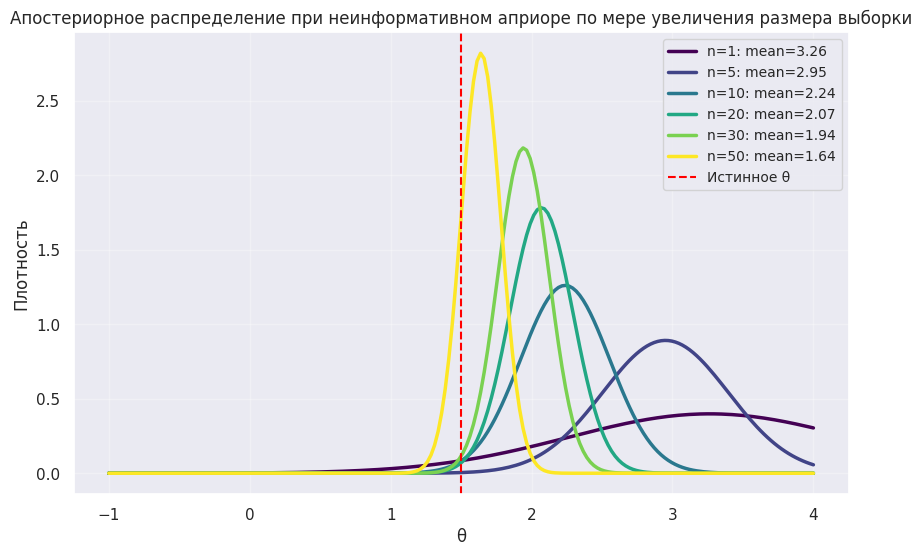

95% доверительный интервал (неинформативный априор): (1.3633785074431322, 1.9177400371829978)
Попало ли истинное значение в интервал? True


In [18]:
np.random.seed(0)
true_theta_norm = 1.5
n_norm = 50
sample_norm = norm(loc=true_theta_norm, scale=1).rvs(size=n_norm)

# Неинформативный априор: считаем, что sigma_0^2 очень большое
mu_0_noninf = 0.0
sigma_0_noninf = 1e6

# Будем обновлять апостериор по мере накопления данных
grid_norm = np.linspace(-1, 4, 200)

post_means = []
post_stds = []
sample_sizes = [1, 5, 10, 20, 30, 50]

for size in sample_sizes:
    current_data = sample_norm[:size]
    sum_x = np.sum(current_data)
    # Формула для апостериорных параметров при норм. априоре и известной дисперсии
    post_mean_noninf = ( (mu_0_noninf/(sigma_0_noninf**2)) + sum_x ) / ( (1/(sigma_0_noninf**2)) + size )
    post_var_noninf = 1 / ((1/(sigma_0_noninf**2)) + size)
    post_means.append(post_mean_noninf)
    post_stds.append(np.sqrt(post_var_noninf))

plt.figure(figsize=(10,6))
colors = plt.cm.viridis(np.linspace(0,1,len(sample_sizes)))

for i, size in enumerate(sample_sizes):
    posterior_noninf = norm(loc=post_means[i], scale=post_stds[i])
    plt.plot(grid_norm, posterior_noninf.pdf(grid_norm),
             label=f'n={size}: mean={post_means[i]:.2f}',
             lw=2.5, color=colors[i])

plt.axvline(x=true_theta_norm, color='red', linestyle='--', label='Истинное θ')

plt.title('Апостериорное распределение при неинформативном априоре по мере увеличения размера выборки')
plt.xlabel('θ')
plt.ylabel('Плотность')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.show()

# CI, вероятность и т.д. аналогично предыдущему
ci_low_noninf = posterior_noninf.ppf(0.025)
ci_high_noninf = posterior_noninf.ppf(0.975)
print("95% доверительный интервал (неинформативный априор):", (ci_low_noninf, ci_high_noninf))
print("Попало ли истинное значение в интервал?", ci_low_noninf <= true_theta_norm <= ci_high_noninf)


*Апостериор тоже нормальный. По мере получения данных он становится уже и сдвигается к истинному среднему, причём неинформативный априор быстро «уступает» влияние данным. На графике видно, как итоговый апостериор сосредотачивается вокруг истинного значения θ, согласуясь с теорией о нормальной сопряжённости.*

**Вывод**: В целом результаты экспериментов подтверждают теоретические ожидания от сопряжённых априорных распределений. При рассмотрении экспоненциального распределения с гамма-априором апостериорное распределение остаётся гамма-распределением и по мере поступления данных всё более точно оценивает истинный параметр θ: математическое ожидание и мода сдвигаются к реальной величине, а доверительный интервал с высокой вероятностью включает истинное значение. В случае нормального распределения с нормальным априором апостериор также остаётся в том же семействе и становится всё уже по мере увеличения объёма выборки, концентрируясь вокруг истинного параметра. Даже при неинформативном априоре данные быстро доминируют в формировании оценок, и апостериор стремится к истинному среднему. Таким образом, все наблюдения согласуются с теорией: сопряжённые априоры упрощают обновление апостериорных оценок, а апостериорные распределения с ростом количества данных всё точнее отражают действительные параметры.

---
## Задача 3 (5 баллов)

Предположим, что летом вы отправились отдыхать на побережье теплого моря. Во время плавания в воде вас кто-то укусил, причем виновника увидеть не получилось. Вы подозреваете, что это может быть медуза, мурена или черепаха. Сравните вероятности для разных животных того, что вы повстречались с конкретным животным при условии полученного укуса.

Вероятность встретить конкретное животное в данном море и вероятность укуса оцените адекватным образом на основе имеющейся в интернете информации. При решении задачи приводите только значения вероятностей. Рассмотрите случаи Черного, Средиземного и Красного морей.

In [14]:
p_animals_black = [0.6, 0.3, 0.1]
p_bite_if_meet_black = [0.05, 0.7, 0.2]

p_animals_med = [0.4, 0.4, 0.2]
p_bite_if_meet_med = [0.1, 0.5, 0.3]

p_animals_red = [0.2, 0.5, 0.3]
p_bite_if_meet_red = [0.05, 0.6, 0.4]

def posterior_bite(p_animals, p_bite_if_meet):
    denom = sum(p*a for p,a in zip(p_bite_if_meet, p_animals))
    return [(p*b)/denom for p,b in zip(p_animals, p_bite_if_meet)]

print("Черное море:", posterior_bite(p_animals_black, p_bite_if_meet_black))
print("Средиземное море:", posterior_bite(p_animals_med, p_bite_if_meet_med))
print("Красное море:", posterior_bite(p_animals_red, p_bite_if_meet_red))


Черное море: [0.11538461538461538, 0.8076923076923076, 0.07692307692307694]
Средиземное море: [0.13333333333333333, 0.6666666666666666, 0.19999999999999996]
Красное море: [0.023255813953488375, 0.6976744186046512, 0.27906976744186046]


---
## Задача 4 (10 баллов)

В качестве байесовского доверительного интервала обычно рассматривают *область наибольшей плотности* (HDR, high density region) апостериорного распределения.

Если $q(t)$ &mdash; плотность некоторого распределения, то множество $A$ называется $\alpha$-HDR, если
* для некоторой $c > 0$ выполнено $\forall x \in A: q(t) \geqslant c$ и $\forall x \notin A: q(t) < c$, то есть внутри $A$ плотность выше, чем вне $A$;
* вероятность события $A$ не меньше $\alpha$
$$\int\limits_A q(t) dt \geqslant \alpha.$$

Как и для доверительных интервалов, при возможности стоит рассматривать такое множество, на котором достигается равенство в последнем неравенстве.

На схеме ниже приведена двумодальная плотность и визуализированы 0.75-HDR, состоящая из двух интервалов, а также доверительные интервалы, построенные с помощью среднего и дисперсии, а также квантилей.

![](https://i.stack.imgur.com/Dy89t.png)


Напишите функцию, вычисляющую HDR для распределения $Beta(\alpha, \beta)$.

*Совет.* Используйте бинпоиск.

In [19]:
import numpy as np
import scipy.stats as sps

def beta_hdr(alpha, a, b, tol=1e-7, max_iter=100):
    '''
    Вычисляет HDR уровня alpha для Beta(a,b).
    Возвращает интервал (l, r).
    '''
    dist = sps.beta(a, b)

    # Определим моду
    if a>1 and b>1:
        mode = (a-1)/(a+b-2)
    elif a<=1 and b<=1:
        # U-образная: HDR будет (0,1) если alpha близко к 1, иначе сложнее.
        # Для простоты вернём весь интервал, или провести приближение
        return (0.0, 1.0)
    elif a<=1:
        # Мода у 0
        mode = 0.0
    else:
        # b<=1 => мода у 1
        mode = 1.0

    max_pdf = dist.pdf(mode)

    def solve_for_x(c, left_side=True):
        # Бинарный поиск, чтобы найти x, где pdf(x)=c
        # Если left_side=True, ищем на отрезке [0, mode], иначе [mode, 1]
        low = 0.0 if left_side else mode
        high = mode if left_side else 1.0

        for _ in range(max_iter):
            mid = 0.5*(low+high)
            val = dist.pdf(mid)
            if (val > c) == left_side:
                # Если ищем слева: val>c значит надо идти левее или правее?
                # left_side=True: мы хотим найти точку пересечения, если val>c, надо сдвинуться ближе к краю
                # На самом деле:
                # Если left_side: при mid pdf(mid)>c, чтобы найти точку пересечения, надо смещать high=mid
                # иначе low=mid
                if val > c:
                    low = mid
                else:
                    high = mid
            else:
                # Это означает, что мы "перешагнули" через точку
                if val > c:
                    low = mid
                else:
                    high = mid
        return 0.5*(low+high)

    def area_above(c):
        # Если c выше максимума плотности, площадь будет 0
        if c>max_pdf:
            return 0.0, 0.0, 0.0

        # Найдём точки l и r, где pdf(x)=c
        # слева от mode:
        l = solve_for_x(c, left_side=True)
        # справа от mode:
        r = solve_for_x(c, left_side=False)

        area = dist.cdf(r)-dist.cdf(l)
        return area, l, r

    # Бинарный поиск по c
    low_c = 0.0
    high_c = max_pdf
    for _ in range(max_iter):
        mid_c = 0.5*(low_c+high_c)
        area, l, r = area_above(mid_c)
        if area > alpha:
            # Чтобы уменьшить площадь, нужно повысить c (плотность)
            low_c = mid_c
        else:
            high_c = mid_c

        if abs(area - alpha)<tol:
            return (l, r)

    # По окончании итераций возвращаем последний найденный интервал
    area, l, r = area_above(0.5*(low_c+high_c))
    return (l, r)
